# HLS Design Space Exploration - Data Preparation

This notebook documents the data preparation pipeline for the **db4hls** dataset for **Multi-Objective Optimization (MOO)**.

## Key Insight: Conflicting Objectives

For a valid MOO problem, we need **conflicting objectives** to find a Pareto front:

| Objective | Metric | Correlation with LUT |
|-----------|--------|---------------------|
| **Area** | `hls_lut`, `hls_ff` | +1.0, +0.74 (aligned) |
| **Speed** | `average_latency` | **-0.09** (conflicting!) |

The negative correlation between Area and Latency creates the classic **Speed vs. Size** trade-off.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load processed data
X = pd.read_parquet('../data/processed/features.parquet')
y = pd.read_parquet('../data/processed/targets.parquet')

print(f"Features shape: {X.shape}")
print(f"Targets shape:  {y.shape}")
print(f"\nTarget columns: {list(y.columns)}")

Features shape: (43992, 262)
Targets shape:  (43992, 4)

Target columns: ['hls_lut', 'hls_ff', 'average_latency', 'best_latency']


## Target Variables (Multi-Objective)

| Column | Type | Description | Optimization |
|--------|------|-------------|--------------|
| `hls_lut` | Area | LUT resource usage | Minimize |
| `hls_ff` | Area | Flip-flop usage | Minimize |
| `average_latency` | Timing | Average clock cycles | Minimize |
| `best_latency` | Timing | Best-case cycles | Minimize |

In [12]:
# Target statistics
print("Target Statistics:")
print(y.describe().round(1))

Target Statistics:
        hls_lut    hls_ff  average_latency  best_latency
count   43992.0   43992.0          43992.0       43992.0
mean    18844.5    7447.0         138899.9      131192.4
std     17245.4    8387.5         686015.0      687277.8
min       533.0     209.0             33.0          33.0
25%      9003.0    2374.0           9554.0        3695.0
50%     20615.0    8327.0           9554.0        9554.0
75%     20615.0    8327.0          34121.0        9554.0
max    610422.0  343237.0       11407569.0    11407569.0


Correlation Matrix:
                 hls_lut  hls_ff  average_latency  best_latency
hls_lut            1.000   0.737           -0.090        -0.084
hls_ff             0.737   1.000           -0.063        -0.058
average_latency   -0.090  -0.063            1.000         1.000
best_latency      -0.084  -0.058            1.000         1.000


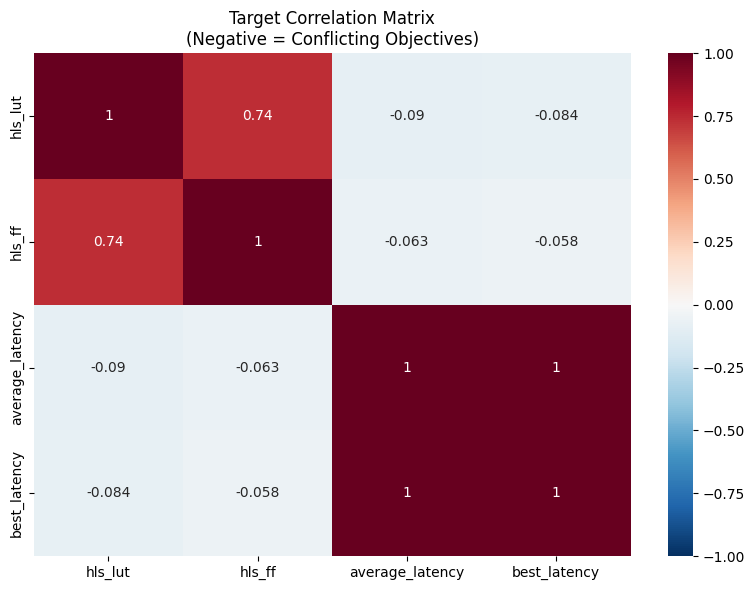

In [13]:
# Correlation matrix - key for MOO
print("Correlation Matrix:")
corr = y.corr()
print(corr.round(3))

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='RdBu_r', center=0, vmin=-1, vmax=1)
plt.title('Target Correlation Matrix\n(Negative = Conflicting Objectives)')
plt.tight_layout()
plt.show()

## The Pareto Trade-off: Area vs. Latency

This is the classic engineering trade-off:
- **Lower latency** → More parallelism → More hardware → Higher LUT usage
- **Lower area** → Sequential execution → Slower → Higher latency

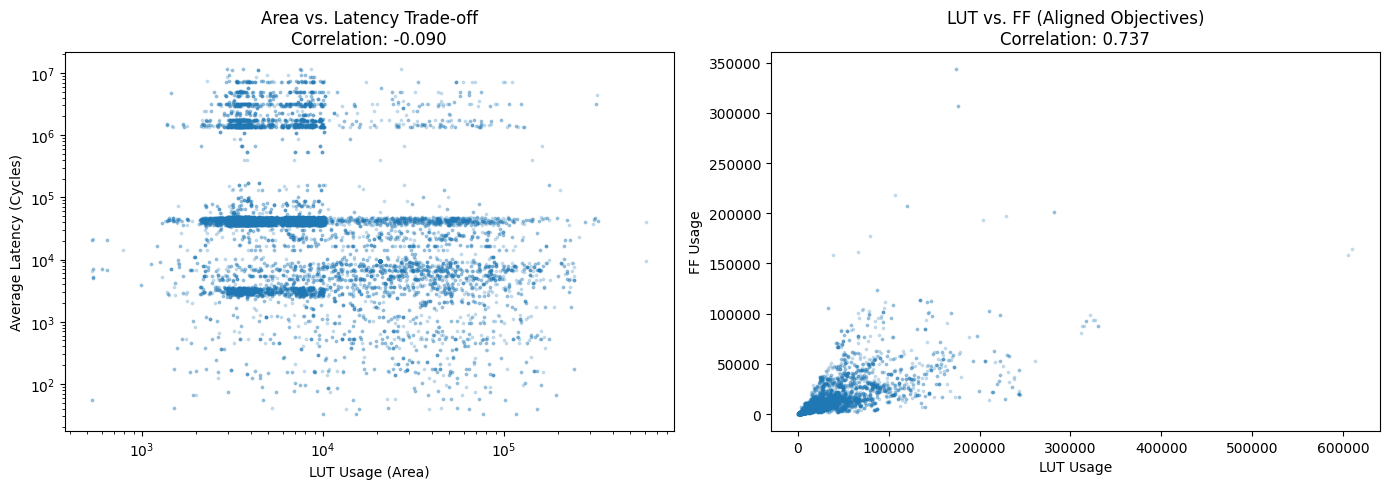

In [14]:
# Pareto front visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# LUT vs Average Latency
ax = axes[0]
ax.scatter(y['hls_lut'], y['average_latency'], alpha=0.2, s=3)
ax.set_xlabel('LUT Usage (Area)')
ax.set_ylabel('Average Latency (Cycles)')
ax.set_title(f'Area vs. Latency Trade-off\nCorrelation: {y["hls_lut"].corr(y["average_latency"]):.3f}')
ax.set_xscale('log')
ax.set_yscale('log')

# LUT vs FF (correlated - not a trade-off)
ax = axes[1]
ax.scatter(y['hls_lut'], y['hls_ff'], alpha=0.2, s=3)
ax.set_xlabel('LUT Usage')
ax.set_ylabel('FF Usage')
ax.set_title(f'LUT vs. FF (Aligned Objectives)\nCorrelation: {y["hls_lut"].corr(y["hls_ff"]):.3f}')

plt.tight_layout()
plt.show()

## Feature Variables (HLS Configuration Knobs)

262 one-hot encoded features from 57 raw parameters:

| Parameter Type | Description | Example Values |
|---------------|-------------|----------------|
| **Resource Binding** | Memory type | `RAM_1P_BRAM`, `RAM_2P_BRAM` |
| **Array Partitioning** | How arrays split | `block`, `cyclic`, factor: 1-512 |
| **Loop Unrolling** | Parallelization | 1, 2, 4, 8, 16, 32, ... |
| **Inlining** | Function inlining | `on`, `off` |

In [15]:
# Feature breakdown
print(f"Total features: {len(X.columns)}")
print("\nSample feature columns:")
for col in list(X.columns)[:15]:
    print(f"  - {col}")

Total features: 262

Sample feature columns:
  - param_23
  - param_0_RAM_2P_BRAM
  - param_0_block
  - param_0_cyclic
  - param_1_1024
  - param_1_104
  - param_1_128
  - param_1_16
  - param_1_192
  - param_1_2
  - param_1_2048
  - param_1_208
  - param_1_24
  - param_1_256
  - param_1_32


## Quick Model Example

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

# Prepare data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a simple RF for each target
print("Random Forest Baseline (R² scores):")
for col in y.columns:
    rf = RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train[col])
    y_pred = rf.predict(X_test)
    r2 = r2_score(y_test[col], y_pred)
    print(f"  {col:20s}: R² = {r2:.3f}")

Random Forest Baseline (R² scores):
  hls_lut             : R² = 0.244
  hls_ff              : R² = 0.166
  average_latency     : R² = 0.677
  best_latency        : R² = 0.673


## Usage

```python
# Full pipeline
from src.data_prep import load_and_prepare
master_df, X, y = load_and_prepare()

# Or load pre-processed
X = pd.read_parquet('data/processed/features.parquet')
y = pd.read_parquet('data/processed/targets.parquet')
```

## File Structure

```
data/processed/
├── features.parquet  # 43,992 × 262
├── targets.parquet   # 43,992 × 4 (LUT, FF, avg_latency, best_latency)
└── master.parquet    # Full merged data
```

Loading data...
Error: Run data_prep.py first to generate parquet files!

Training AI Models on 43992 designs...
  -> Area Model Accuracy (R²):  0.281
  -> Speed Model Accuracy (R²): 0.937
CRITICAL WARNING: Models are too weak for optimization. Check data.

Running MOO (Finding Pareto Front)...
  -> Generated 10000 designs.
  -> Found 8 optimal designs (Pareto Front).

Result saved to 'pareto_front.png'. Open it to see your thesis result.


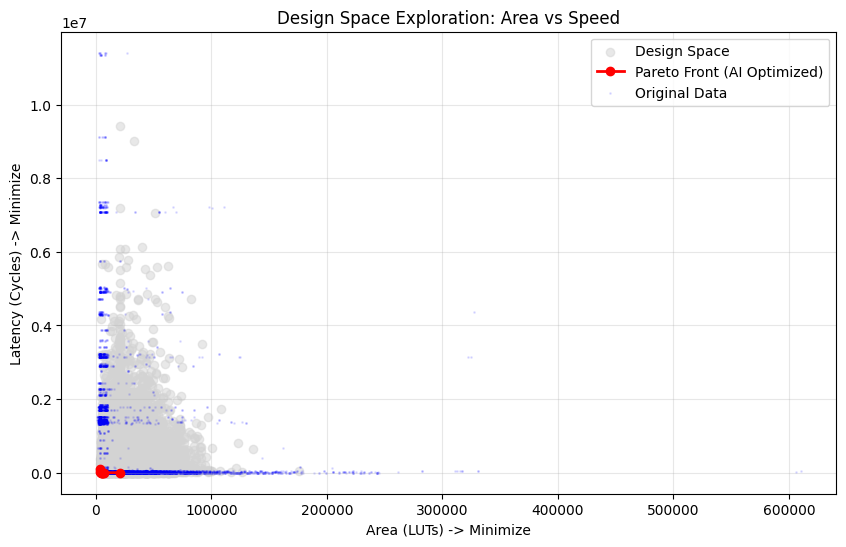

: 

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

# --- 1. Load Data ---
print("Loading data...")
try:
    X = pd.read_parquet('data/processed/features.parquet')
    y = pd.read_parquet('data/processed/targets.parquet')
except FileNotFoundError:
    print("Error: Run data_prep.py first to generate parquet files!")
    exit()

# Select specific objectives for MOO
# We want to MINIMIZE both (LUTs for Area, Latency for Speed)
obj_area = "hls_lut"
obj_speed = "average_latency"

y = y[[obj_area, obj_speed]]

# --- 2. Train AI Models (The Surrogates) ---
print(f"\nTraining AI Models on {len(X)} designs...")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model 1: Area Predictor
model_area = RandomForestRegressor(n_estimators=50, n_jobs=-1, random_state=42)
model_area.fit(X_train, y_train[obj_area])
r2_area = r2_score(y_test[obj_area], model_area.predict(X_test))

# Model 2: Speed Predictor
model_speed = RandomForestRegressor(n_estimators=50, n_jobs=-1, random_state=42)
model_speed.fit(X_train, y_train[obj_speed])
r2_speed = r2_score(y_test[obj_speed], model_speed.predict(X_test))

print(f"  -> Area Model Accuracy (R²):  {r2_area:.3f}")
print(f"  -> Speed Model Accuracy (R²): {r2_speed:.3f}")

if r2_area < 0.5 or r2_speed < 0.5:
    print("CRITICAL WARNING: Models are too weak for optimization. Check data.")

# --- 3. Design Space Exploration (The Optimization) ---
print("\nRunning MOO (Finding Pareto Front)...")

# Strategy: Generate 10,000 random configurations and ask the AI "What happens?"
# (In a real thesis, you'd use NSGA-II, but Random Search is a strong baseline)

# Generate synthetic inputs based on feature probabilities
# (This assumes binary features from One-Hot Encoding)
n_samples = 10000
X_synthetic = pd.DataFrame(np.random.randint(0, 2, size=(n_samples, X.shape[1])), columns=X.columns)

# Predict outcomes using our trained AI
pred_area = model_area.predict(X_synthetic)
pred_speed = model_speed.predict(X_synthetic)

# --- 4. Identify Pareto Optimal Points ---
def is_pareto_efficient(costs):
    """
    Find the pareto-efficient points
    :param costs: An (n_points, n_costs) array
    :return: A (n_points, ) boolean array, indicating whether each point is Pareto efficient
    """
    is_efficient = np.ones(costs.shape[0], dtype=bool)
    for i, c in enumerate(costs):
        if is_efficient[i]:
            # Keep any point 'j' that is NOT dominated by 'i'
            # Dominated means: j is worse than i in ALL objectives
            # We want to minimize, so 'worse' means higher value
            is_efficient[is_efficient] = np.any(costs[is_efficient] < c, axis=1)  # Remove points strictly worse than c
            is_efficient[i] = True  # Keep self
    return is_efficient

# Combine predictions
results = np.column_stack((pred_area, pred_speed))
pareto_mask = is_pareto_efficient(results)
pareto_front = results[pareto_mask]

# Sort for clean plotting
pareto_front = pareto_front[np.argsort(pareto_front[:, 0])]

print(f"  -> Generated {n_samples} designs.")
print(f"  -> Found {len(pareto_front)} optimal designs (Pareto Front).")

# --- 5. Visualization ---
plt.figure(figsize=(10, 6))
# Plot all synthetic designs (The "Cloud")
plt.scatter(pred_area, pred_speed, c='lightgray', alpha=0.5, label='Design Space')
# Plot the Pareto Front (The "Edge")
plt.plot(pareto_front[:, 0], pareto_front[:, 1], 'r-o', linewidth=2, label='Pareto Front (AI Optimized)')
# Plot original data for context
plt.scatter(y[obj_area], y[obj_speed], c='blue', s=1, alpha=0.1, label='Original Data')

plt.xlabel('Area (LUTs) -> Minimize')
plt.ylabel('Latency (Cycles) -> Minimize')
plt.title('Design Space Exploration: Area vs Speed')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('pareto_front.png')
print("\nResult saved to 'pareto_front.png'. Open it to see your thesis result.")